In [3]:
%load_ext autoreload
%autoreload 2

import torch, json, time, numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

from sv3.nn import FunctionalModelJac, MLP, SmallResNet
from sv3.svd_sgd import SVDOptimizer
import sys
sys.path.append('..')

import torch
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if hasattr(torch.backends,'mps') and torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: cuda


In [4]:
# CIFAR-10 dataset & config
from experiments.datasets.all_datasets import CIFAR10Dataset

cifar = CIFAR10Dataset(for_mlp=False)

train_dataset = cifar.train_dataset
test_dataset  = cifar.val_dataset

In [5]:
batch_size = 64              # reduce to mitigate Jacobian memory
input_dim  = 32*32*3
hidden_layers = [1024]*8  # MLP size
resnet_width = 8
output_size = 10
num_epochs = 20

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

# train normal supervised model

In [6]:
#model_sup = MLP(input_dim, hidden_layers, output_size).to(device)
model_sup = SmallResNet(num_classes=output_size, width=resnet_width).to(device)
optimizer = torch.optim.AdamW(model_sup.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

num_epochs = 20
losses_direct = defaultdict(list)
for epoch in range(num_epochs):
    epoch_losses = defaultdict(list)
    model_sup.train()
    for xb, yb in tqdm(train_loader):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        ypred = model_sup(xb)
        loss = loss_fn(ypred, yb)
        loss.backward()
        optimizer.step()
        epoch_losses['train'].append(loss.item())
    model_sup.eval()
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            ypred = model_sup(xb)
            loss = loss_fn(ypred, yb)
            epoch_losses['val'].append(loss.item())
            acc = (ypred.argmax(dim=1) == yb).float().mean().item()
            epoch_losses['val_acc'].append(acc)
    # Save batch-wise losses
    losses_direct['train_batch'].extend(epoch_losses['train'])
    losses_direct['val_batch'].extend(epoch_losses['val'])
    # Save epoch-averaged losses
    for k,v in epoch_losses.items():
        losses_direct[k].append(np.mean(v))

100%|██████████| 782/782 [00:15<00:00, 50.83it/s]


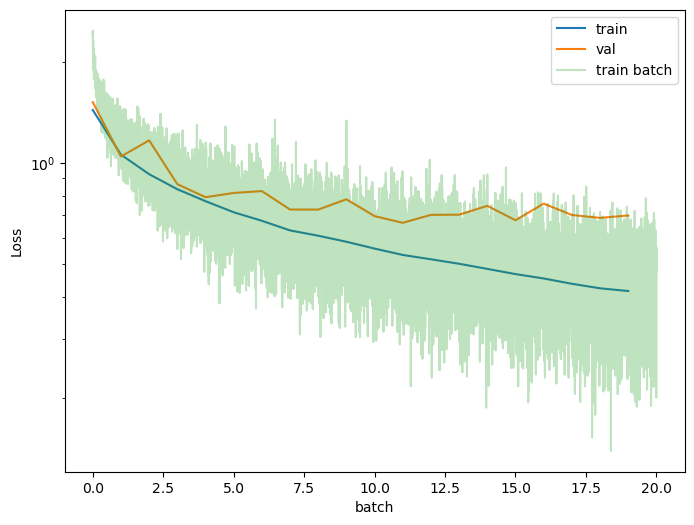

In [7]:
plt.figure(figsize=(8,6))
plt.plot(losses_direct['train'], label='train')
plt.plot(losses_direct['val'], label='val')
xvals = np.linspace(0,num_epochs,len(losses_direct['train_batch']))
plt.plot(xvals, losses_direct['train_batch'], label='train batch', alpha=0.3)
#plt.plot(losses_direct['val_batch'], label='val')
plt.xlabel('batch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

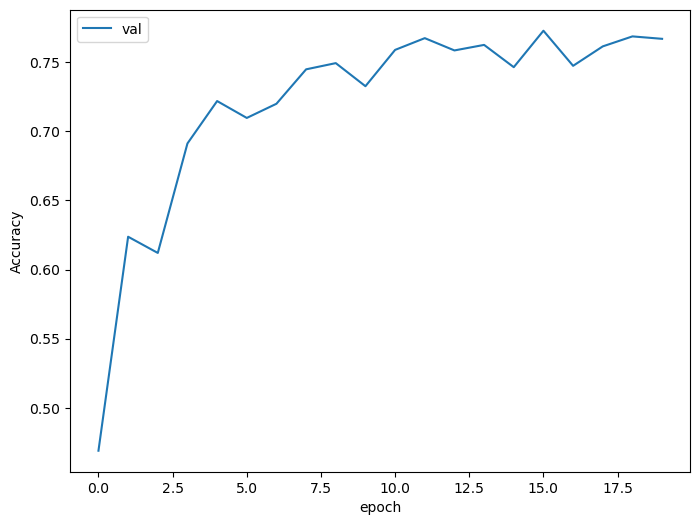

In [8]:
plt.figure(figsize=(8,6))
plt.plot(losses_direct['val_acc'], label='val')
plt.xlabel('epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# svd loss

In [11]:
#mlp_svd = MLP(input_dim=input_dim,hidden_dims=hidden_layers,output_dim=output_size).to(device)
mlp_svd = SmallResNet(num_classes=output_size, width=resnet_width).to(device)
loss_fn = nn.CrossEntropyLoss(reduction='none')
loss_lambda = lambda pred, y: loss_fn(pred, y).squeeze()

lr_svd = 0.1
k_svd = batch_size
rtol = 1e-3 
model_svd = FunctionalModelJac(mlp_svd, loss_lambda, device)
opt_svd = SVDOptimizer(model_svd, lr=lr_svd, k=k_svd, rtol=rtol, track_svd_info=True)

num_epochs = 20
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

losses_svd = defaultdict(list)

# save untrained validation loss
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        ypred = model_svd.evaluate(xb)
        loss = loss_lambda(ypred, yb).mean()
        losses_svd['val_init'].append(loss.item())

# Ensure all computations are done without gradients
with torch.no_grad():
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        epoch_losses = defaultdict(list)
        for xb, yb in tqdm(train_loader):
            xb, yb = xb.to(device), yb.to(device)
            batch = (xb, yb)
            losses = model_svd.loss_and_grad(batch)
            opt_svd.step()
            epoch_losses['train'].append(losses.mean().item())
        
        for xb, yb in test_loader:
            xb, yb = xb.to(device).detach(), yb.to(device).detach()
            ypred = model_svd.evaluate(xb)
            loss = loss_lambda(ypred, yb).mean()
            epoch_losses['val'].append(loss.item())
        
        # Save batch-wise losses
        losses_svd['train_batch'].extend(epoch_losses['train'])
        losses_svd['val_batch'].extend(epoch_losses['val'])
        # Save epoch-averaged losses
        for k_name, v in epoch_losses.items():
            losses_svd[k_name].append(np.mean(v))
torch.compiler.reset()

/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/jax/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:236: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


Epoch 1/20


  0%|          | 0/781 [00:00<?, ?it/s]/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
100%|██████████| 781/781 [01:03<00:00, 12.24it/s]


Epoch 2/20


100%|██████████| 781/781 [00:33<00:00, 22.99it/s]


...

100%|██████████| 781/781 [00:30<00:00, 25.55it/s]


Epoch 19/20


100%|██████████| 781/781 [00:30<00:00, 25.34it/s]


Epoch 20/20


100%|██████████| 781/781 [00:30<00:00, 25.32it/s]


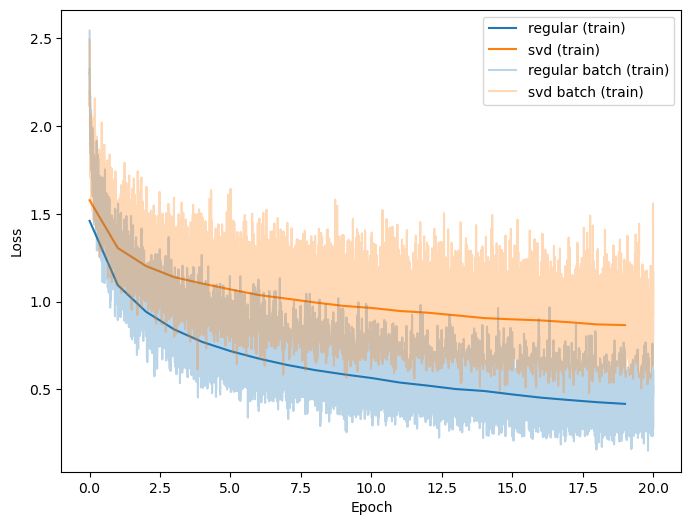

In [12]:
plt.figure(figsize=(8,6))
plt.plot(losses_direct['train'], label='regular (train)',color="C0")
plt.plot(losses_svd['train'], label='svd (train)',color="C1")
xvals = np.linspace(0,num_epochs,len(losses_direct['train_batch']))
xvals_svd = np.linspace(0,num_epochs,len(losses_svd['train_batch']))    
plt.plot(xvals, losses_direct['train_batch'], label='regular batch (train)', alpha=0.3)
plt.plot(xvals_svd, losses_svd['train_batch'], label='svd batch (train)', alpha=0.3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
#plt.yscale('log')
plt.legend()
plt.show()